C:\Users\WANG\AppData\Local\Temp\ipykernel_14224\4021958555.py:281: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Blues')   # 比 viridis 更亮、更偏蓝绿
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PS backend determines usetex status solely based on rcParams['text.usetex'] and does not support having usetex=True only for some elements; this element will thus be rendered as if usetex=False.


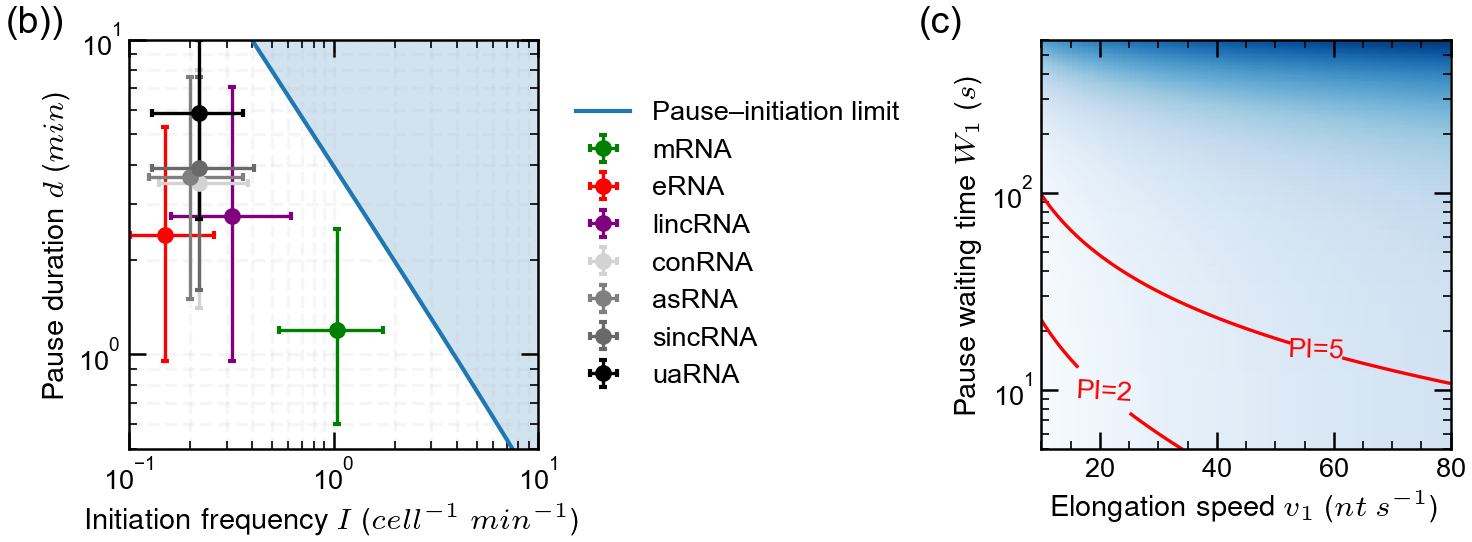

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from src.plot_style import configure_journal_style
from src.utils import compute_gate_equilibrium_weights
import matplotlib.gridspec as gridspec
import seaborn as sns


# 最大暂停区并发 Pol II 数：N_max（无量纲）
N_max = 4.0  

# promoter-proximal 区域长度（nt）
L_p = 100.0  

# 有效延伸速度（nt/s）
v_eff = 50.0 

# W 的取值范围：pause 等待时间（秒）
W_min = 5.0      
W_max = 600.0    
n_points = 400


use_log_scale = True 

# ==========================
# 计算上限曲线：I_max(W)
# ==========================

# 平均 pause 区域穿越时间（秒）：tau_travel = L_p / v_eff
tau_travel = L_p / v_eff  # s

# W 轴：pause 等待时间（秒）
if use_log_scale:
    W_sec = np.logspace(np.log10(W_min), np.log10(W_max), n_points)
else:
    W_sec = np.linspace(W_min, W_max, n_points)

d_minute = W_sec / 60.0

# 上限曲线：I_max(W) = N_max / (W + tau_travel)
I_max_per_sec = N_max / (W_sec + tau_travel)   # 1 / s
I_max_per_min = 60.0 * I_max_per_sec           # 1 / min

# ==========================
# 论文的圆点坐标（I, d）
# ==========================

data_points = [

    ("mRNA",    1.04, 1.2, 0.54, 1.75, 0.6, 2.5),
    ("eRNA",    0.15, 2.4, 0.101, 0.26, 0.95, 5.3),
    ("lincRNA", 0.32, 2.75, 0.16, 0.62, 0.95, 7.08),
    ("conRNA",  0.22, 3.5, 0.14, 0.38, 1.4, 8),
    ("asRNA",   0.20,3.65, 0.125,0.36, 1.5, 7.6),
    ("sincRNA", 0.22, 3.9, 0.13, 0.41, 1.6, 7.6),
    ("uaRNA",   0.22, 5.85, 0.13, 0.36, 2.7, 10),
]

colors = {
    "uaRNA":   "black",
    "sincRNA": "dimgray",
    "asRNA":   "gray",
    "conRNA": "lightgray",
    "lincRNA": "purple",
    "eRNA":    "red",
    "mRNA":    "green",
}

# ==========================
# 画图
# ==========================
configure_journal_style()
plt.rcParams['pdf.fonttype'] = 3
plt.rcParams['ps.fonttype']  = 3
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(5, 1.8), sharey=False)


if use_log_scale:
    ax1.set_xscale('log')
    ax1.set_yscale('log')


ax1.plot(I_max_per_min, d_minute, lw=1, label=r'Pause–initiation limit')


I_right = I_max_per_min.max() * 10.0  
ax1.fill_betweenx(d_minute, I_max_per_min, I_right,
                 where=I_right >= I_max_per_min,
                 alpha=0.2)


for name, I_center, d_center, I_min, I_max, d_min, d_max in data_points:

    xerr = np.array([[I_center - I_min], [I_max - I_center]])
    yerr = np.array([[d_center - d_min], [d_max - d_center]])


    c = colors.get(name, "blue")  

    ax1.errorbar(
        I_center, d_center,
        xerr=xerr, yerr=yerr,
        fmt='o',
        markersize=3,
        capsize=1.0,
        elinewidth=0.8,
        color=c,
        label=name
    )
ax1.set_xlim(0.1, 10)
ax1.set_ylim(0.5, 10)
ax1.set_box_aspect(1)

ax1.set_xlabel(r'Initiation frequency $I$ ($cell$$^{-1}$ $min$$^{-1}$)', usetex=True)
ax1.set_ylabel(r'Pause duration $d$ ($min$)', usetex=True)


# 图例
ax1.legend(
    loc="center left",               
    bbox_to_anchor=(1.0, 0.5),     
    frameon=False,
    fontsize=6.5
)

ax1.grid(True, which='both', ls='--', alpha=0.1)

###########################################################################


def pausing_index(
    W,
    v,
    lambdas,
    pi,
    L,
    prom_len=250.0,  # Δx_prom in nt (e.g., 250 bp window)
    body_start=1000.0,  # gene body starts after this nt
):
    """
    Compute the Pausing Index proxy given per-gate W_i (s) and v_i (nt/s).

    Parameters
    ----------
    W : array-like, shape (d,)
        Mean pause waiting times W_i (s), per arrival-state i.
    v : array-like, shape (d,)
        Mean elongation speeds v_i (nt/s), per arrival-state i.
    lambdas : array-like, shape (d,)
        Arrival rates λ_i (1/s), per gate i.
    pi : array-like, shape (d,)
        Stationary weights π_i of the gate CTMC.
    L : float
        Gene length in nt.
    prom_len : float
        Promoter window length Δx_prom (nt).
    body_start : float
        Start position (nt) of the gene-body window.

    Returns
    -------
    PI : float
        Pausing Index proxy (dimensionless).
    """
    W = np.asarray(W, float)
    v = np.asarray(v, float)
    lam = np.asarray(lambdas, float)
    pi = np.asarray(pi, float)

    # Window lengths
    L_body = max(float(L) - float(body_start), 1e-9)
    Dx = float(prom_len)

    # Promoter-window expected time per initiation in gate i:
    #   W_i (pause at TSS) + (Δx_prom / v_i) (early transit within promoter window)
    t_prom_i = W + Dx / v

    # Gene-body expected time per initiation in gate i:
    #   L_body / v_i
    t_body_i = L_body / v

    num = np.sum(pi * lam * t_prom_i) / Dx
    den = np.sum(pi * lam * t_body_i) / L_body

    PI = num / den
    return float(PI)


def pi_grid_for_gate(
    i_star,
    W_grid,
    v_grid,
    W_base,
    v_base,
    lambdas,
    pi,
    L,
    prom_len=250.0,
    body_start=1000.0,
):
    """
    Evaluate PI on a 2D grid of (W_i, v_i) for a chosen gate i_star, holding others at baseline.
    Returns a 2D array of shape (len(W_grid), len(v_grid)).
    """
    W_grid = np.asarray(W_grid, float)
    v_grid = np.asarray(v_grid, float)

    PI = np.empty((W_grid.size, v_grid.size), dtype=float)
    for a, Wi in enumerate(W_grid):
        for b, vi in enumerate(v_grid):
            W = np.array(W_base, float)
            v = np.array(v_base, float)
            W[i_star] = Wi
            v[i_star] = vi
            PI[a, b] = pausing_index(
                W, v, lambdas, pi, L, prom_len=prom_len, body_start=body_start
            )
    return PI

d = 3
L = 6000.0  # nt

# Gate CTMC (Q) and stationary weights π
Q = np.array(
    [[-0.006, 0.005, 0.001],
    [0.050, -0.052, 0.002],
    [0.005, 0.002, -0.007],],float,
    )
pi = compute_gate_equilibrium_weights(Q)  # shape (d,)

# Arrival rates
lambdas = np.array([0.020, 0.003, 0.001], float)

# Baseline W (s) and v (nt/s)
W_base = np.array([5.0, 30.0, 240.0], float)
# ≈ [2.5, 2.0, 1.5] kb/min
v_base = np.array([41.667, 33.333, 25.0], float)

# Windows for PI
prom_len = 250.0  # nt in promoter window (e.g., ±250 bp around TSS)
body_start = 1000.0  # nt; gene body window starts after 1 kb

# ---- Grids for (W_i, v_i) ----
# W grid: 5 s ~ 10 min
W_grid = np.geomspace(5.0, 600.0, 80)  # seconds
# v grid: 10 ~ 80 nt/s (≈ 0.6 ~ 4.8 kb/min)
v_grid = np.linspace(10.0, 80.0, 80)  # nt/s

# ---- Compute PI grids for each gate ----
grids = []
for i_star in range(d):
    PI = pi_grid_for_gate(
        i_star,
        W_grid,
        v_grid,
        W_base,
        v_base,
        lambdas,
        pi,
        L,
        prom_len=prom_len,
        body_start=body_start,
    )
    grids.append(PI)

Z = grids[0]                     # 只取第一个 gate: (W_0, v_0)
Zplot = np.log10(Z)

extent = [v_grid.min(), v_grid.max(), W_grid.min(), W_grid.max()]


cmap = plt.cm.get_cmap('Blues')   
Zmin, Zmax = Zplot.min(), Zplot.max()
vmin = Zmin + 0 * (Zmax - Zmin)  

im = ax2.imshow(
    Zplot,
    origin="lower",
    aspect="auto",
    extent=extent,
    interpolation="nearest",
    cmap=cmap,
    vmin=vmin,
    vmax=Zmax,
)


# Z = grids[0]                     # 只取第一个 gate: (W_0, v_0)
# Zplot = np.log10(Z)

# # Extent for imshow: x = v, y = W
# extent = [v_grid.min(), v_grid.max(), W_grid.min(), W_grid.max()]

# im = ax2.imshow(
#     Zplot,
#     origin="lower",
#     aspect="auto",
#     extent=extent,
#     interpolation="nearest",
# )

# Contours at PI = 1, 2, 5
V = [1.0, 2.0, 5.0]
CS = ax2.contour(v_grid, W_grid, Z, levels=V, colors="r", linewidths=0.8)
ax2.clabel(CS, inline=True, fontsize=6.5, fmt=lambda v: f"PI={v:g}")


ax2.set_xlabel(r'Elongation speed $v_1$ ($nt$ $s$$^{-1}$)', usetex=True)

ax2.set_ylabel(r'Pause waiting time $W_1$ ($s$)', usetex=True)


ax2.set_xscale("linear")
ax2.set_yscale("log")
ax2.set_ylim(W_grid.min(), W_grid.max())


ax2.tick_params(axis='y', which='both', labelleft=True)

ax2.set_box_aspect(1)

# cbar = fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
# cbar.set_label(r"$\log_{10}{PI}$", usetex=True)

ax1.text(-0.3, 1.00, '(b)', transform=ax1.transAxes,
        fontsize=9, va='bottom', ha='left')
ax2.text(-0.3, 1.00, '(c)', transform=ax2.transAxes,
        fontsize=9, va='bottom', ha='left')
plt.subplots_adjust(hspace=0.5, wspace=1.5)  # 纵横间距
plt.savefig('Fig5.pdf', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


C:\Users\WANG\AppData\Local\Temp\ipykernel_14224\3410575522.py:213: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Blues")


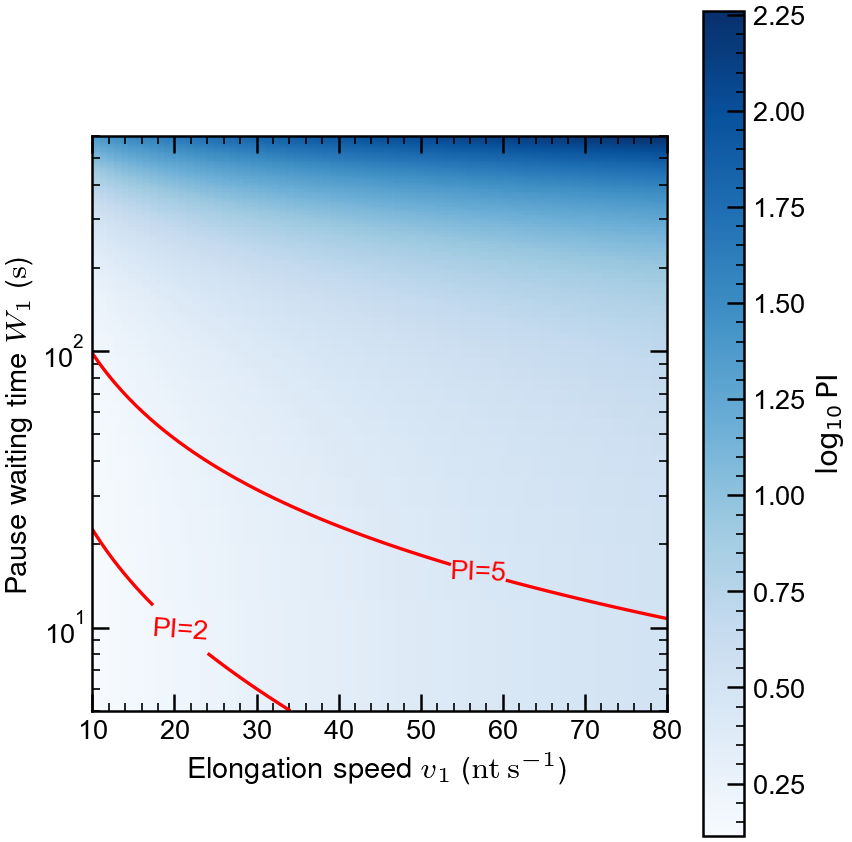

In [3]:
import numpy as np
import matplotlib.pyplot as plt


def compute_gate_equilibrium_weights(Q):
    """
    Compute stationary distribution π of a CTMC with generator Q.

    Parameters
    ----------
    Q : array-like, shape (d, d)
        Generator matrix.

    Returns
    -------
    pi : ndarray, shape (d,)
        Stationary distribution.
    """
    w, v = np.linalg.eig(Q.T)
    idx = np.argmin(np.abs(w))  # eigenvalue closest to 0
    pi = np.real(v[:, idx])
    pi = np.abs(pi)
    pi = pi / pi.sum()
    return pi


def pausing_index(
    W,
    v,
    lambdas,
    pi,
    L,
    prom_len=250.0,  # ℓ_P in nt
    body_start=1000.0,  # kept only for backward-compatibility (unused in new formula)
):
    r"""
    Compute the Pausing Index (PI) proxy given per-gate W_i (s) and v_i (nt/s),
    using the new approximation

        PI ≈ ((L - ℓ_P)/ℓ_P) ·
              [ Σ_i π_i λ_i ( E[W_i] + ℓ_P / v_i ) ]
            / [ Σ_i π_i (λ_i (L - ℓ_P) / v_i) ].

    Here ℓ_P is taken to be `prom_len`, and |G| = L - ℓ_P.

    Parameters
    ----------
    W : array-like, shape (d,)
        Mean pause waiting times W_i (s), per arrival-state i.
    v : array-like, shape (d,)
        Mean elongation speeds v_i (nt/s), per arrival-state i.
    lambdas : array-like, shape (d,)
        Arrival rates λ_i (1/s), per gate i.
    pi : array-like, shape (d,)
        Stationary weights π_i of the gate CTMC.
    L : float
        Gene length in nt.
    prom_len : float
        Promoter window length ℓ_P (nt).
    body_start : float
        Unused in the new approximation; kept for API compatibility.

    Returns
    -------
    PI : float
        Pausing Index proxy (dimensionless).
    """
    W = np.asarray(W, float)
    v = np.asarray(v, float)
    lam = np.asarray(lambdas, float)
    pi = np.asarray(pi, float)

    # Promoter length ℓ_P and gene-body length |G| = L - ℓ_P
    ell_P = float(prom_len)
    L_body = max(float(L) - ell_P, 1e-9)

    # Expected time per initiation in promoter window: E[W_i] + ℓ_P / v_i
    t_prom_i = W + ell_P / v

    # Expected time per initiation in gene body G: (L - ℓ_P) / v_i
    t_body_i = L_body / v

    # Weighted sums over gate states
    num = np.sum(pi * lam * t_prom_i)
    den = np.sum(pi * lam * t_body_i)

    # New PI formula
    PI = (L_body / ell_P) * (num / den)
    return float(PI)


def pi_grid_for_gate(
    i_star,
    W_grid,
    v_grid,
    W_base,
    v_base,
    lambdas,
    pi,
    L,
    prom_len=250.0,
    body_start=1000.0,
):
    """
    Evaluate PI on a 2D grid of (W_i, v_i) for a chosen gate i_star,
    holding other gates at baseline values.

    Parameters
    ----------
    i_star : int
        Index of the gate whose (W_i, v_i) are varied.
    W_grid : array-like
        Grid of W_i values (s).
    v_grid : array-like
        Grid of v_i values (nt/s).
    W_base : array-like, shape (d,)
        Baseline W values (s) for all gates.
    v_base : array-like, shape (d,)
        Baseline v values (nt/s) for all gates.
    lambdas : array-like, shape (d,)
        Arrival rates λ_i (1/s).
    pi : array-like, shape (d,)
        Stationary distribution π_i.
    L : float
        Gene length (nt).
    prom_len : float
        Promoter length ℓ_P (nt).
    body_start : float
        Ignored in the new approximation (kept for compatibility).

    Returns
    -------
    PI_grid : ndarray, shape (len(W_grid), len(v_grid))
        PI values on the (W_i, v_i) grid for gate i_star.
    """
    W_grid = np.asarray(W_grid, float)
    v_grid = np.asarray(v_grid, float)

    PI = np.empty((W_grid.size, v_grid.size), dtype=float)
    for a, Wi in enumerate(W_grid):
        for b, vi in enumerate(v_grid):
            W = np.array(W_base, float)
            v = np.array(v_base, float)
            W[i_star] = Wi
            v[i_star] = vi
            PI[a, b] = pausing_index(
                W, v, lambdas, pi, L, prom_len=prom_len, body_start=body_start
            )
    return PI


if __name__ == "__main__":
    # ----------------- Parameters -----------------
    d = 3
    L = 6000.0  # nt

    # Gate CTMC (Q) and stationary weights π
    Q = np.array(
        [
            [-0.006, 0.005, 0.001],
            [0.050, -0.052, 0.002],
            [0.005, 0.002, -0.007],
        ],
        float,
    )
    pi = compute_gate_equilibrium_weights(Q)  # shape (d,)

    # Arrival rates λ_i (1/s)
    lambdas = np.array([0.020, 0.003, 0.001], float)

    # Baseline W (s) and v (nt/s)
    W_base = np.array([5.0, 30.0, 240.0], float)
    # ≈ [2.5, 2.0, 1.5] kb/min
    v_base = np.array([41.667, 33.333, 25.0], float)

    # Windows for PI
    prom_len = 250.0   # ℓ_P in nt
    body_start = 1000.0  # (unused in new formula, but kept for compatibility)

    # ---- Grids for (W_i, v_i) ----
    # W grid: 5 s ~ 10 min
    W_grid = np.geomspace(5.0, 600.0, 80)  # seconds
    # v grid: 10 ~ 80 nt/s (≈ 0.6 ~ 4.8 kb/min)
    v_grid = np.linspace(10.0, 80.0, 80)   # nt/s

    # ---- Compute PI grids for each gate ----
    grids = []
    for i_star in range(d):
        PI = pi_grid_for_gate(
            i_star,
            W_grid,
            v_grid,
            W_base,
            v_base,
            lambdas,
            pi,
            L,
            prom_len=prom_len,
            body_start=body_start,
        )
        grids.append(PI)

    # 只画第一个 gate: (W_0, v_0)
    Z = grids[0]
    Zplot = np.log10(Z)

    # Extent for imshow: x = v, y = W
    extent = [v_grid.min(), v_grid.max(), W_grid.min(), W_grid.max()]

    fig, ax2 = plt.subplots(figsize=(3.0, 3.0))

    # 比较浅的蓝色配色
    cmap = plt.cm.get_cmap("Blues")
    Zmin, Zmax = Zplot.min(), Zplot.max()
    vmin = Zmin  # 如需压缩深色范围可以调高 vmin

    im = ax2.imshow(
        Zplot,
        origin="lower",
        aspect="auto",
        extent=extent,
        interpolation="nearest",
        cmap=cmap,
        vmin=vmin,
        vmax=Zmax,
    )

    # Contours at PI = 1, 2, 5
    V = [1.0, 2.0, 5.0]
    CS = ax2.contour(v_grid, W_grid, Z, levels=V, colors="r", linewidths=0.8)
    ax2.clabel(CS, inline=True, fontsize=6.5, fmt=lambda v: f"PI={v:g}")

    # 推荐：如果没有 TeX，把 usetex=True 去掉
    ax2.set_xlabel(r'Elongation speed $v_1$ ($\mathrm{nt}\,\mathrm{s}^{-1}$)', usetex=True)
    ax2.set_ylabel(r'Pause waiting time $W_1$ ($\mathrm{s}$)', usetex=True)

    ax2.set_xscale("linear")
    ax2.set_yscale("log")
    ax2.set_ylim(W_grid.min(), W_grid.max())

    ax2.tick_params(axis="y", which="both", labelleft=True)
    ax2.set_box_aspect(1)

    cbar = plt.colorbar(im, ax=ax2)
    cbar.set_label(r'$\log_{10} \mathrm{PI}$', rotation=90)

    plt.tight_layout()
    plt.show()
